In [ ]:
from qcodes.instrument_drivers.Keysight import KeysightP9374A, KeysightPNATrace
import pyvisa
import matplotlib.pyplot as plt
import numpy as np
import pandas as df

In [ ]:
rm = pyvisa.ResourceManager()
resources = rm.list_resources()
resources

In [2]:
KEYSIGHT_VISA_ADDRESS = "TCPIP0::boettcher-lab-0::hislip_PXI10_CHASSIS1_SLOT1_INDEX0::INSTR"
vna = KeysightP9374A('vna',KEYSIGHT_VISA_ADDRESS)

Connected to: Keysight Technologies P9374A (serial:MY57213750, firmware:A.19.30.08) in 0.12s


In [3]:
# I think you need to create a trace (start, stop, ,IFBW, etc.) associated with the VNA object then run it using trace.run_sweep(). Can double-check with Claude.
vna.output.set(0)

In [4]:
# Make sure the trace is S21.
if vna.traces[0].trace.get() != 'S21':
    RuntimeError("Not running S21!")
if len(vna.traces) != 1:
    RuntimeError("More than one trace active!")

In [ ]:
def keysight_vna_trace(
    vna,
    sweep_start,
    sweep_stop,
    sweep_power=-10,
    sweep_ifbw=1e3,
    sweep_points=1000,
    sweep_averages=10
    ):
    
    # Check that we are going to sweep the ports we want to sweep (i.e. don't drive output of HEMT)!
    
    if vna.traces[0].trace.get() != 'S21':
        RuntimeError("Not running S21!")
    if len(vna.traces) != 1:
        RuntimeError("More than one trace active!")
    tr = vna.traces[0]

    vna.power.set(sweep_power)
    vna.if_bandwidth.set(sweep_ifbw)
    vna.start.set(sweep_start)
    vna.stop.set(sweep_stop)
    vna.points.set(sweep_points)
    vna.averages.set(sweep_averages)

    # Now enable averaging and power output.
    vna.averages_enabled.set(1)
    vna.output.set(1)

    # Now run trace with run_sweep() if averages are enabled it runs it N times.
    tr.run_sweep()

    return vna.frequency_axis, tr.real(), tr.imaginary()

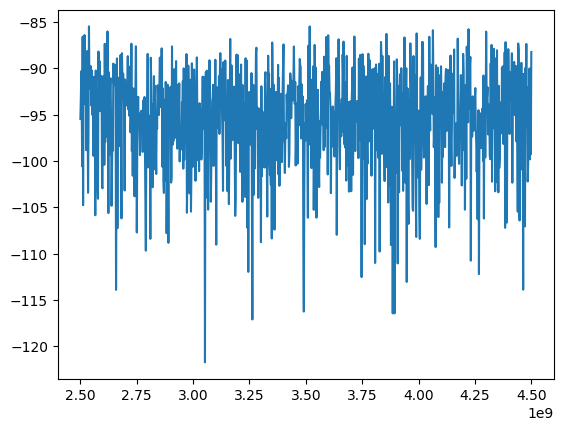

In [31]:
plt.plot(freq_axis,10*np.log10(re_data**2 + im_data**2))

In [ ]:
def keysight_vna_trace(
    vna,
    start_freq,
    stop_freq,
    num_points,
    power,
    ifbw,
    averages):

    vna.power.set(power)
    vna.ifbw.set(ifbw)
    vna.start.set(start_freq)
    vna.stop.set(stop_freq)
    vna.points.set(num_points)
    vna.averages_enabled.set(1)
    vna.averages.set(averages)

    # Set up sweeping.
    vna.averages_enabled.set(1)